## **Objective:** Port the wildfire sensor placement QUBO to Pasqal's neutral atom quantum computer using analog Hamiltonian evolution.

**Key Differences from Gate-Model QAOA:**
- **Geometric encoding:** Atom positions in 2D array directly represent sensor locations
- **Rydberg blockade:** Natural spatial separation constraint (atoms within blockade radius cannot both be excited)
- **Analog evolution:** Direct Hamiltonian time-evolution instead of gate circuits
- **Larger scale potential:** 100+ atoms possible (vs 15 qubits max for CPU QAOA)

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────────
import os, json, time, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Try to import rasterio for TIF sampling
try:
    import rasterio
    HAS_RASTERIO = True
except ImportError:
    HAS_RASTERIO = False
    print('⚠ rasterio not installed. Install with: pip install rasterio')

# Pasqal Pulser SDK
try:
    from pulser import Pulse, Sequence, Register
    from pulser.devices import DigitalAnalogDevice
    from pulser.waveforms import RampWaveform, ConstantWaveform
    from pulser_simulation import QutipEmulator
    HAS_PULSER = True
    print('✓ Pulser SDK available')
except ImportError:
    HAS_PULSER = False
    print('⚠ Pulser not installed. Install with: pip install pulser pulser-simulation')

# Classical solvers for comparison
from collections import Counter

# Check for real data
REAL_CSV = "../data/processed/optimized_sensor_network.csv"
RISK_TIF = "../data/processed/daily_fire_risk_map.tif"
HAS_REAL_DATA = os.path.exists(REAL_CSV)

if HAS_REAL_DATA:
    print(f'✓ Real sensor data found: {REAL_CSV}')
else:
    print(f'⚠ Real data not found at {REAL_CSV}, will use synthetic')

print('\n── Setup complete ──')

✓ Pulser SDK available
✓ Real sensor data found: ../data/processed/optimized_sensor_network.csv

── Setup complete ──


---
## 1. Instance Generation (Same as Original Notebook)

We'll use the same instance format for fair comparison across platforms.

In [2]:
def haversine(lat1, lon1, lat2, lon2):
    """Distance in meters."""
    R = 6371000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def sample_risk_from_tif(lats, lons):
    """Sample risk scores from daily_fire_risk_map.tif"""
    if not os.path.exists(RISK_TIF) or not HAS_RASTERIO:
        return None
    
    try:
        with rasterio.open(RISK_TIF) as src:
            risk_scores = []
            for lat, lon in zip(lats, lons):
                try:
                    row, col = src.index(lon, lat)
                    if 0 <= row < src.height and 0 <= col < src.width:
                        val = src.read(1)[row, col]
                        risk_scores.append(max(0, float(val)))
                    else:
                        risk_scores.append(0.0)
                except:
                    risk_scores.append(0.0)
            
            risk_scores = np.array(risk_scores)
            if risk_scores.max() > 0:
                risk_norm = risk_scores / risk_scores.max()
                print(f'  ✓ Sampled risk scores from TIF: min={risk_scores.min():.2f}, max={risk_scores.max():.2f}')
                return risk_norm
    except Exception as e:
        print(f'  ⚠️ Could not read TIF: {e}')
    
    return None

def generate_instance(N, K, output_path, use_real_data=True):
    """Generate instance from real CSV with TIF risk sampling or synthetic fallback."""
    
    if use_real_data and HAS_REAL_DATA:
        df = pd.read_csv(REAL_CSV)
        if len(df) < N:
            print(f'    CSV has only {len(df)} rows, generating synthetic for N={N}')
            use_real_data = False
        else:
            df = df.head(N).copy()
            lats = df['latitude'].values
            lons = df['longitude'].values
            
            # Try to get real risk scores from TIF
            risk_norm = sample_risk_from_tif(lats, lons)
            
            if risk_norm is not None:
                risk_source = "REAL - sampled from daily_fire_risk_map.tif"
            elif 'risk_score_norm' in df.columns:
                risk_norm = df['risk_score_norm'].values
                risk_source = "REAL - from CSV (risk_score_norm)"
            elif 'risk_score_raw' in df.columns:
                risk_raw = df['risk_score_raw'].values
                risk_norm = risk_raw / risk_raw.max() if risk_raw.max() > 0 else risk_raw
                risk_source = "REAL - from CSV (risk_score_raw, normalized)"
            else:
                # Assign based on layer (wildland = higher risk)
                base = np.random.uniform(0.3, 0.6, N)
                if 'layer' in df.columns:
                    boost = np.where(df['layer'] == 'Wildland_Perimeter', 0.25, 0)
                    risk_norm = base + boost
                else:
                    risk_norm = base
                risk_norm = risk_norm / risk_norm.max()
                risk_source = "SYNTHETIC - layer-based"
            
            sensor_ids = df['sensor_id'].values if 'sensor_id' in df.columns else [f'SENSOR_{i:02d}' for i in range(N)]
            layers = df['layer'].values if 'layer' in df.columns else ['Unknown'] * N
            data_source = f'REAL - {REAL_CSV}'
    
    if not use_real_data or not HAS_REAL_DATA:
        # ── SYNTHETIC DATA (fallback) ───────────────────────────────────────────
        np.random.seed(42)
        lats = np.random.uniform(19.03, 19.18, N)
        lons = np.random.uniform(-104.35, -104.15, N)
        base = np.random.uniform(0.2, 0.7, N)
        risk_norm = base / base.max()
        sensor_ids = [f'SENSOR_{i:02d}' for i in range(N)]
        layers = ['Asset_Defense'] * (N//2) + ['Wildland_Perimeter'] * (N - N//2)
        risk_source = "SYNTHETIC - uniform random"
        data_source = "SYNTHETIC"
    
    # Compute distance matrix
    dist_matrix = np.zeros((N, N))
    for i in range(N):
        for j in range(i+1, N):
            d = haversine(lats[i], lons[i], lats[j], lons[j])
            dist_matrix[i, j] = d
            dist_matrix[j, i] = d
    
    # Build instance dict
    instance = {
        "metadata": {
            "instance_name": f"manzanillo_pasqal_N{N}_K{K}",
            "version": "1.0",
            "created_date": datetime.now().strftime("%Y-%m-%d"),
            "platform": "Pasqal neutral atoms",
            "risk_source": risk_source,
            "data_source": data_source
        },
        "problem": {
            "N": N,
            "K_budget": K,
            "min_separation_m": 2000,
            "lambda_budget": 5.0,
            "lambda_spatial": 12.0
        },
        "candidates": [],
        "distance_matrix": dist_matrix.tolist()
    }
    
    for i in range(N):
        instance['candidates'].append({
            "id": i,
            "sensor_id": str(sensor_ids[i]),
            "latitude": float(lats[i]),
            "longitude": float(lons[i]),
            "layer": str(layers[i]),
            "risk_score_norm": float(risk_norm[i])
        })
    
    # Save
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, 'w') as f:
        json.dump(instance, f, indent=2)
    
    print(f'  Instance saved: {output_path}')
    print(f'  Risk source: {risk_source}')
    print(f'  N={N}, K={K}')
    
    return instance

print('✓ Instance generator defined with TIF sampling')

✓ Instance generator defined with TIF sampling


---
## 2. Pasqal-Specific: Coordinate Transformation

**Challenge:** Pasqal atoms are positioned in 2D plane with units of micrometers (μm), but our sensors are at geographic coordinates (lat/lon) spanning kilometers.

**Solution:** 
1. Convert lat/lon to local Cartesian coordinates (meters)
2. Scale to μm and fit within device constraints
3. Preserve relative distances for Rydberg blockade radius mapping

In [3]:
def latlon_to_cartesian(lats, lons):
    """Convert lat/lon to local Cartesian (meters) using simple projection."""
    # Reference point: center of coordinates
    lat0 = np.mean(lats)
    lon0 = np.mean(lons)
    
    # Approximate meters per degree at this latitude
    m_per_deg_lat = 111320  # ~constant
    m_per_deg_lon = 111320 * np.cos(np.radians(lat0))
    
    x = (lons - lon0) * m_per_deg_lon
    y = (lats - lat0) * m_per_deg_lat
    
    return x, y

def scale_to_pulser_register(x_m, y_m, target_span_um=50.0):
    """
    Scale Cartesian coordinates (meters) to Pulser register (micrometers).
    
    Pasqal device constraints:
    - Atom spacing: typically 4-50 μm
    - Max array size: ~100 μm × 100 μm
    - Rydberg blockade radius: ~10 μm (tunable via detuning/Rabi frequency)
    
    Args:
        x_m, y_m: coordinates in meters
        target_span_um: desired span of register (μm)
    
    Returns:
        x_um, y_um: coordinates in micrometers
        scale_factor: meters per micrometer (for interpreting blockade radius)
    """
    # Center at origin
    x_m = x_m - np.mean(x_m)
    y_m = y_m - np.mean(y_m)
    
    # Find current span
    span_m = max(np.ptp(x_m), np.ptp(y_m))
    
    # Scale to target span (in μm)
    scale = target_span_um / (span_m * 1e6)  # m → μm scaling
    x_um = x_m * 1e6 * scale
    y_um = y_m * 1e6 * scale
    
    # Compute scale factor: meters/μm
    m_per_um = span_m / target_span_um
    
    return x_um, y_um, m_per_um

def instance_to_register(instance, target_span_um=50.0, min_sep_m=2000):
    """
    Convert instance to Pulser Register.
    
    Returns:
        register: Pulser Register object
        blockade_radius_um: Rydberg blockade radius (μm) corresponding to min_sep_m
        m_per_um: scale factor for interpretation
    """
    lats = np.array([c['latitude'] for c in instance['candidates']])
    lons = np.array([c['longitude'] for c in instance['candidates']])
    
    # Convert to Cartesian
    x_m, y_m = latlon_to_cartesian(lats, lons)
    
    # Scale to μm
    x_um, y_um, m_per_um = scale_to_pulser_register(x_m, y_m, target_span_um)
    
    # Compute blockade radius in μm
    blockade_radius_um = min_sep_m / m_per_um
    
    # Build register
    coords = {f"q{i}": (x_um[i], y_um[i]) for i in range(len(lats))}
    register = Register(coords)
    
    print(f'  Register: {len(coords)} atoms')
    print(f'  Span: {np.ptp(x_um):.1f} × {np.ptp(y_um):.1f} μm')
    print(f'  Scale: {m_per_um:.1f} m/μm')
    print(f'  Blockade radius (for {min_sep_m}m separation): {blockade_radius_um:.2f} μm')
    
    return register, blockade_radius_um, m_per_um

print('✓ Coordinate transformation functions defined')

✓ Coordinate transformation functions defined


---
## 3. Pasqal Quantum Optimization: Maximum Weighted Independent Set (MWIS)

**Problem Mapping:**

Our QUBO:
```
H = -sum(r[i]*x[i]) + λ_budget*(sum(x[i])-K)^2 + λ_spatial*sum_{i<j, d<2000m} x[i]*x[j]
```

Maps to **Maximum Weighted Independent Set (MWIS)**:
- **Nodes:** sensors with weights = risk scores
- **Edges:** pairs with distance < 2000m (spatial constraint)
- **Objective:** Select K nodes maximizing total weight, no two adjacent

**Pasqal Rydberg Hamiltonian:**
```
H = -Ω/2 * sum(σ_x^i) + Δ * sum(n_i) - sum(r[i]*n_i) + V_ij * sum_{i<j} n_i*n_j
```

Where:
- `Ω(t)`: Rabi frequency (drives transitions |g⟩ ↔ |r⟩)
- `Δ(t)`: Detuning (energy bias for Rydberg state)
- `n_i = |r⟩⟨r|`: Rydberg state projector
- `V_ij = C6/d_ij^6`: Van der Waals interaction (blockade)

**Adiabatic Protocol:**
1. **Initial state:** All atoms in ground state |g...g⟩
2. **Ramp up Ω:** Create equal superposition
3. **Sweep Δ from negative to positive:** Adiabatically follow ground state
4. **Measure:** Atoms in |r⟩ = selected sensors

**Budget Constraint (K sensors):**
We can't directly encode hard cardinality constraint in analog Hamiltonian. Options:
1. **Post-selection:** Run multiple shots, keep solutions with sum(n_i) ≈ K
2. **Penalty term:** Add global detuning proportional to (sum(n_i) - K)^2 (approximated)
3. **Accept soft constraint:** Let Rydberg blockade + risk weights naturally select ~K sensors

We'll use **option 3** for simplicity (analog to PennyLane QAOA without strict budget enforcement).

In [4]:
def build_pasqal_sequence(register, risk_weights, blockade_radius_um, duration_us=4.0, max_rabi_MHz=2.5):
    """
    Build Pulser sequence for quantum adiabatic optimization.
    
    Args:
        register: Pulser Register
        risk_weights: array of normalized risk scores (0-1)
        blockade_radius_um: Rydberg blockade radius (μm)
        duration_us: total evolution time (microseconds)
        max_rabi_MHz: maximum Rabi frequency (MHz)
    
    Returns:
        seq: Pulser Sequence
    """
    N = len(register.qubits)
    
    # Device (DigitalAnalogDevice supports analog mode)
    device = DigitalAnalogDevice
    
    # Create sequence
    seq = Sequence(register, device)
    
    # Declare global analog channel
    seq.declare_channel('global', 'rydberg_global')
    
    # Device constraints from DigitalAnalogDevice.rydberg_global:
    # max_abs_detuning: 125.66 rad/μs (≈ 20 MHz)
    # max_amp: 62.83 rad/μs (≈ 10 MHz)
    
    # Safe parameters within device limits
    max_rabi_rad_us = min(max_rabi_MHz * 2 * np.pi, 50)  # Cap at ~8 MHz
    max_detuning_rad_us = 100  # ~16 MHz, well within 125.66 limit
    
    # ── Phase 1: Ramp up Rabi frequency (prepare equal superposition) ──
    ramp_duration = int(duration_us * 1000 * 0.2)  # 20% of total (ns)
    omega_ramp = RampWaveform(ramp_duration, 0, max_rabi_rad_us)
    delta_initial = -max_detuning_rad_us  # Negative detuning (prefer ground state)
    delta_ramp = ConstantWaveform(ramp_duration, delta_initial)
    
    pulse_ramp = Pulse(omega_ramp, delta_ramp, 0)  # phase=0
    seq.add(pulse_ramp, 'global')
    
    # ── Phase 2: Adiabatic sweep (Δ: negative → positive) ──
    sweep_duration = int(duration_us * 1000 * 0.6)  # 60% of total
    omega_const = ConstantWaveform(sweep_duration, max_rabi_rad_us)
    
    # Sweep detuning from negative to small positive
    delta_final = max_detuning_rad_us * 0.3  # Small positive (~5 MHz)
    delta_sweep = RampWaveform(sweep_duration, delta_initial, delta_final)
    
    pulse_sweep = Pulse(omega_const, delta_sweep, 0)
    seq.add(pulse_sweep, 'global')
    19
    # ── Phase 3: Ramp down Rabi (project to computational basis) ──
    rampdown_duration = int(duration_us * 1000 * 0.2)  # 20%
    omega_down = RampWaveform(rampdown_duration, max_rabi_rad_us, 0)
    delta_down = ConstantWaveform(rampdown_duration, delta_final)
    
    pulse_down = Pulse(omega_down, delta_down, 0)
    seq.add(pulse_down, 'global')
    
    print(f'  Sequence duration: {duration_us:.2f} μs')
    print(f'  Max Rabi: {max_rabi_rad_us/(2*np.pi):.2f} MHz ({max_rabi_rad_us:.2f} rad/μs)')
    print(f'  Detuning sweep: {delta_initial/(2*np.pi):.2f} → {delta_final/(2*np.pi):.2f} MHz')
    
    return seq

print('✓ Pasqal sequence builder defined')

✓ Pasqal sequence builder defined


In [5]:
def build_pasqal_sequence_improved(register, risk_weights, blockade_radius_um, duration_us=6.0, max_rabi_MHz=2.5):
    """
    Improved sequence with slower adiabatic sweep for better constraint satisfaction.
    """
    N = len(register.qubits)
    
    # Device
    device = DigitalAnalogDevice
    
    # Create sequence
    seq = Sequence(register, device)
    
    # Declare global analog channel
    seq.declare_channel('global', 'rydberg_global')
    
    # Safe parameters within device limits
    max_rabi_rad_us = min(max_rabi_MHz * 2 * np.pi, 50)
    max_detuning_rad_us = 100
    
    # Longer duration for better adiabaticity (6μs instead of 4μs)
    # ── Phase 1: Ramp up Rabi frequency ──
    ramp_duration = int(duration_us * 1000 * 0.15)  # 15% of total
    omega_ramp = RampWaveform(ramp_duration, 0, max_rabi_rad_us)
    delta_initial = -max_detuning_rad_us
    delta_ramp = ConstantWaveform(ramp_duration, delta_initial)
    
    pulse_ramp = Pulse(omega_ramp, delta_ramp, 0)
    seq.add(pulse_ramp, 'global')
    
    # ── Phase 2: Hold at max Rabi while sweeping Δ ──
    # Longer hold time for better adiabatic following
    hold_duration = int(duration_us * 1000 * 0.5)  # 50% of total
    omega_hold = ConstantWaveform(hold_duration, max_rabi_rad_us)
    
    # Sweep detuning from negative to positive
    delta_final = max_detuning_rad_us * 0.5  # Higher positive detuning for stronger Rydberg bias
    delta_sweep = RampWaveform(hold_duration, delta_initial, delta_final)
    
    pulse_hold = Pulse(omega_hold, delta_sweep, 0)
    seq.add(pulse_hold, 'global')
    
    # ── Phase 3: Ramp down Rabi ──
    rampdown_duration = int(duration_us * 1000 * 0.35)  # 35% of total
    omega_down = RampWaveform(rampdown_duration, max_rabi_rad_us, 0)
    delta_down = ConstantWaveform(rampdown_duration, delta_final)
    
    pulse_down = Pulse(omega_down, delta_down, 0)
    seq.add(pulse_down, 'global')
    
    print(f'  Sequence duration: {duration_us:.2f} μs')
    print(f'  Max Rabi: {max_rabi_rad_us/(2*np.pi):.2f} MHz')
    print(f'  Detuning sweep: {delta_initial/(2*np.pi):.2f} → {delta_final/(2*np.pi):.2f} MHz')
    
    return seq


def build_pasqal_sequence_strong_blockade(register, risk_weights, blockade_radius_um, duration_us=6.0, max_rabi_MHz=2.0):
    """
    Sequence optimized for strong blockade effect.
    Lower Rabi frequency and higher detuning for stronger constraint enforcement.
    """
    N = len(register.qubits)
    device = DigitalAnalogDevice
    seq = Sequence(register, device)
    seq.declare_channel('global', 'rydberg_global')
    
    # Use lower Rabi frequency for stronger blockade
    max_rabi_rad_us = min(max_rabi_MHz * 2 * np.pi, 40)
    max_detuning_rad_us = 120  # Higher detuning for stronger penalty
    
    # Ramp up
    ramp_duration = int(duration_us * 1000 * 0.1)
    omega_ramp = RampWaveform(ramp_duration, 0, max_rabi_rad_us)
    delta_initial = -max_detuning_rad_us
    delta_ramp = ConstantWaveform(ramp_duration, delta_initial)
    seq.add(Pulse(omega_ramp, delta_ramp, 0), 'global')
    
    # Main sweep - very slow for adiabaticity
    sweep_duration = int(duration_us * 1000 * 0.7)
    omega_sweep = ConstantWaveform(sweep_duration, max_rabi_rad_us)
    delta_final = max_detuning_rad_us * 0.6
    delta_sweep = RampWaveform(sweep_duration, delta_initial, delta_final)
    seq.add(Pulse(omega_sweep, delta_sweep, 0), 'global')
    
    # Ramp down slowly
    rampdown_duration = int(duration_us * 1000 * 0.2)
    omega_down = RampWaveform(rampdown_duration, max_rabi_rad_us, 0)
    delta_down = ConstantWaveform(rampdown_duration, delta_final)
    seq.add(Pulse(omega_down, delta_down, 0), 'global')
    
    print(f'  Strong blockade mode: duration={duration_us}μs, Rabi={max_rabi_MHz}MHz, Detuning range={max_detuning_rad_us/(2*np.pi):.1f}MHz')
    return seq

---
## 4. Simulation & Solution Extraction

Run the sequence on QutipEmulator and extract best solutions.

In [6]:
def solve_pasqal(instance, duration_us=6.0, max_rabi_MHz=2.0, n_shots=2000, sequence_type='strong_blockade'):
    """
    Solve sensor placement using Pasqal neutral atoms.
    
    Args:
        instance: Problem instance
        duration_us: Total evolution time (microseconds)
        max_rabi_MHz: Maximum Rabi frequency (MHz)
        n_shots: Number of measurement shots
        sequence_type: Type of sequence to use ('original', 'improved', or 'strong_blockade')
    
    Returns:
        result dict with coverage, violations, runtime, etc.
    """
    if not HAS_PULSER:
        return {'error': 'Pulser not installed'}
    
    t0 = time.time()
    
    # Build register
    register, blockade_radius_um, m_per_um = instance_to_register(
        instance, 
        target_span_um=50.0,
        min_sep_m=instance['problem']['min_separation_m']
    )
    
    # Risk weights
    risk_weights = np.array([c['risk_score_norm'] for c in instance['candidates']])
    
    # Build sequence based on type
    if sequence_type == 'improved':
        seq = build_pasqal_sequence_improved(
            register, risk_weights, blockade_radius_um,
            duration_us=duration_us, max_rabi_MHz=max_rabi_MHz
        )
    elif sequence_type == 'strong_blockade':
        seq = build_pasqal_sequence_strong_blockade(
            register, risk_weights, blockade_radius_um,
            duration_us=duration_us, max_rabi_MHz=max_rabi_MHz
        )
    else:  # original
        seq = build_pasqal_sequence(
            register, risk_weights, blockade_radius_um,
            duration_us=duration_us, max_rabi_MHz=max_rabi_MHz
        )
    
    # Simulate
    print('  Running QutipEmulator...')
    sim = QutipEmulator.from_sequence(seq)
    results = sim.run()
    
    # Sample from final state
    print(f'  Sampling {n_shots} shots...')
    sampled_states = results.sample_final_state(N_samples=n_shots)
    
    # Count occurrences
    counts = Counter(sampled_states)
    
    # Find best solution with strict constraint enforcement
    N = instance['problem']['N']
    K = instance['problem']['K_budget']
    dist = np.array(instance['distance_matrix'])
    min_sep = instance['problem']['min_separation_m']
    
    best_bitstring = None
    best_score = -np.inf
    best_coverage = 0
    
    # First pass: try to find solutions with ZERO violations
    for bitstring, count in counts.most_common(100):
        x = np.array([int(b) for b in bitstring], dtype=int)
        
        # Check spatial violations
        selected = np.where(x == 1)[0]
        has_violation = False
        for i in selected:
            for j in selected:
                if i < j and 0 < dist[i, j] < min_sep:
                    has_violation = True
                    break
            if has_violation:
                break
        
        # Skip solutions with violations
        if has_violation:
            continue
        
        # For valid solutions, compute coverage
        coverage = float(np.sum(risk_weights * x))
        budget_penalty = abs(x.sum() - K) * 0.2
        score = coverage - budget_penalty
        
        if score > best_score:
            best_score = score
            best_bitstring = bitstring
            best_coverage = coverage
    
    # If no zero-violation solutions found, accept some violations with heavy penalty
    if best_bitstring is None:
        print('  No zero-violation solutions found, accepting some violations...')
        for bitstring, count in counts.most_common(100):
            x = np.array([int(b) for b in bitstring], dtype=int)
            coverage = float(np.sum(risk_weights * x))
            
            selected = np.where(x == 1)[0]
            viol = 0
            for i in selected:
                for j in selected:
                    if i < j and 0 < dist[i, j] < min_sep:
                        viol += 1
            
            # Heavy penalty for violations
            budget_penalty = abs(x.sum() - K) * 0.2
            score = coverage - budget_penalty - viol * 0.5
            
            if score > best_score:
                best_score = score
                best_bitstring = bitstring
                best_coverage = coverage
    
    runtime = time.time() - t0
    
    if best_bitstring is None:
        return {'error': 'No valid solution found'}
    
    # Extract final solution
    x_best = np.array([int(b) for b in best_bitstring], dtype=int)
    selected = np.where(x_best == 1)[0]
    coverage = float(np.sum(risk_weights[selected]))
    
    viol = 0
    for i in selected:
        for j in selected:
            if i < j and 0 < dist[i, j] < min_sep:
                viol += 1
    
    return {
        'coverage': coverage,
        'violations': int(viol),
        'n_selected': int(x_best.sum()),
        'runtime': runtime,
        'duration_us': duration_us,
        'max_rabi_MHz': max_rabi_MHz,
        'n_shots': n_shots,
        'sequence_type': sequence_type,
        'top_bitstring': best_bitstring,
        'counts_top5': dict(counts.most_common(5))
    }

---
## 5. Classical Baselines (for Comparison)

Re-use Greedy and SA from original notebook.

In [7]:
def build_qubo(instance):
    """Build Q matrix from instance."""
    N = instance['problem']['N']
    K = instance['problem']['K_budget']
    lam_b = instance['problem']['lambda_budget']
    lam_s = instance['problem']['lambda_spatial']
    min_sep = instance['problem']['min_separation_m']
    
    r = np.array([c['risk_score_norm'] for c in instance['candidates']])
    dist = np.array(instance['distance_matrix'])
    
    Q = np.zeros((N, N))
    for i in range(N):
        Q[i, i] = -r[i] + lam_b * (1 - 2*K)
    for i in range(N):
        for j in range(i+1, N):
            Q[i, j] = 2 * lam_b
            if 0 < dist[i, j] < min_sep:
                Q[i, j] += 2 * lam_s
    
    return Q, r, dist

def qubo_energy(x, Q):
    return float(x @ Q @ x)

def count_violations(x, dist, min_sep):
    selected = np.where(x == 1)[0]
    viol = 0
    for i in selected:
        for j in selected:
            if i < j and 0 < dist[i, j] < min_sep:
                viol += 1
    return viol

def solve_greedy(instance):
    Q, r, dist = build_qubo(instance)
    K = instance['problem']['K_budget']
    
    t0 = time.time()
    indices = np.argsort(r)[::-1][:K]
    x = np.zeros(len(r), dtype=int)
    x[indices] = 1
    runtime = time.time() - t0
    
    # Create bitstring from x
    bitstring = ''.join(str(int(bit)) for bit in x)
    
    return {
        'coverage': float(r[indices].sum()),
        'energy': float(qubo_energy(x, Q)),
        'violations': int(count_violations(x, dist, instance['problem']['min_separation_m'])),
        'runtime': runtime,
        'n_selected': int(x.sum()),
        'top_bitstring': bitstring,  # Added
        'selected_indices': indices.tolist()  # Added for easier plotting
    }


def solve_sa(instance, seed=None, n_steps=50000):
    if seed is not None:
        np.random.seed(seed)
    
    Q, r, dist = build_qubo(instance)
    N = len(r)
    
    t0 = time.time()
    x = np.random.randint(0, 2, N)
    E = qubo_energy(x, Q)
    best_x, best_E = x.copy(), E
    
    temps = np.linspace(5.0, 0.01, n_steps)
    for T in temps:
        flip = np.random.randint(N)
        x_new = x.copy()
        x_new[flip] = 1 - x_new[flip]
        E_new = qubo_energy(x_new, Q)
        dE = E_new - E
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            x, E = x_new, E_new
            if E < best_E:
                best_x, best_E = x.copy(), E
    
    runtime = time.time() - t0
    selected = np.where(best_x == 1)[0]
    
    # Create bitstring from best_x
    bitstring = ''.join(str(int(bit)) for bit in best_x)
    
    return {
        'coverage': float(r[selected].sum()),
        'energy': float(best_E),
        'violations': int(count_violations(best_x, dist, instance['problem']['min_separation_m'])),
        'runtime': runtime,
        'n_selected': int(best_x.sum()),
        'top_bitstring': bitstring,  # Added
        'selected_indices': selected.tolist()  # Added for easier plotting
    }

---
## 6. Benchmark: Pasqal vs Classical


In [8]:
# ── 6. Benchmark: Classical on Full 25 vs Pasqal on Subsets ──────────────────────

# Create results directory
os.makedirs('benchmark_results/instances', exist_ok=True)
os.makedirs('benchmark_results/results', exist_ok=True)

# ── PART A: Generate FULL 25-candidate instance for classical solvers ──
print("\n" + "="*70)
print("GENERATING FULL INSTANCE FOR CLASSICAL SOLVERS")
print("="*70)

inst_full = generate_instance(25, 8, 'benchmark_results/instances/classical_full_N25_K8.json', use_real_data=True)
print(f"\n✓ Full instance created with {inst_full['problem']['N']} candidates")

# ── PART B: Generate SUBSET instances for Pasqal quantum solver ──
print("\n" + "="*70)
print("GENERATING SUBSET INSTANCES FOR PASQAL QUANTUM SOLVER")
print("="*70)

subset_sizes = [(12, 8), (15, 8), (17, 8)]  # (N, K) for Pasqal
subset_instances = []

for N, K in subset_sizes:
    path = f'benchmark_results/instances/pasqal_subset_N{N}_K{K}.json'
    print(f"\nGenerating N={N}, K={K}...")
    inst = generate_instance(N, K, path, use_real_data=True)
    subset_instances.append((N, K, inst))
    print(f"  Risk source: {inst['metadata']['risk_source']}")
    print(f"  Data source: {inst['metadata']['data_source']}")

print("\n✓ Subset instances generated")

# ── PART C: Run Classical Solvers on FULL 25-candidate problem ──
print("\n" + "="*70)
print("CLASSICAL SOLVERS ON FULL PROBLEM (N=25, K=8)")
print("="*70)

# Greedy on full problem
print("\n  Greedy (Full N=25)...")
res_greedy_full = solve_greedy(inst_full)
print(f"    Coverage: {res_greedy_full['coverage']:.4f}")
print(f"    Violations: {res_greedy_full['violations']}")
print(f"    Selected: {res_greedy_full['n_selected']}/{inst_full['problem']['K_budget']}")
print(f"    Runtime: {res_greedy_full['runtime']:.3f}s")

# Simulated Annealing on full problem (5 seeds)
print("\n  Simulated Annealing (Full N=25, 5 seeds)...")
sa_full_results = []
sa_full_cov = []
sa_full_viol = []
sa_full_time = []
sa_full_bitstrings = []

for i in range(5):
    res = solve_sa(inst_full, seed=i, n_steps=50000)
    sa_full_results.append(res)
    sa_full_cov.append(res['coverage'])
    sa_full_viol.append(res['violations'])
    sa_full_time.append(res['runtime'])
    sa_full_bitstrings.append(res['top_bitstring'])
    print(f"    Seed {i}: Coverage={res['coverage']:.4f}, Violations={res['violations']}, Runtime={res['runtime']:.3f}s")

# Best SA result (by coverage)
best_sa_result = max(sa_full_results, key=lambda x: x['coverage'])

print(f"\n  SA Summary (5 runs):")
print(f"    Coverage: {np.mean(sa_full_cov):.4f} ± {np.std(sa_full_cov):.4f}")
print(f"    Violations: {np.mean(sa_full_viol):.2f} ± {np.std(sa_full_viol):.2f}")
print(f"    Runtime: {np.mean(sa_full_time):.3f} ± {np.std(sa_full_time):.3f}s")


GENERATING FULL INSTANCE FOR CLASSICAL SOLVERS
  ✓ Sampled risk scores from TIF: min=0.00, max=49.14
  Instance saved: benchmark_results/instances/classical_full_N25_K8.json
  Risk source: REAL - sampled from daily_fire_risk_map.tif
  N=25, K=8

✓ Full instance created with 25 candidates

GENERATING SUBSET INSTANCES FOR PASQAL QUANTUM SOLVER

Generating N=12, K=8...
  ✓ Sampled risk scores from TIF: min=0.00, max=45.83
  Instance saved: benchmark_results/instances/pasqal_subset_N12_K8.json
  Risk source: REAL - sampled from daily_fire_risk_map.tif
  N=12, K=8
  Risk source: REAL - sampled from daily_fire_risk_map.tif
  Data source: REAL - ../data/processed/optimized_sensor_network.csv

Generating N=15, K=8...
  ✓ Sampled risk scores from TIF: min=0.00, max=45.83
  Instance saved: benchmark_results/instances/pasqal_subset_N15_K8.json
  Risk source: REAL - sampled from daily_fire_risk_map.tif
  N=15, K=8
  Risk source: REAL - sampled from daily_fire_risk_map.tif
  Data source: REAL - ..

In [9]:
# ── PART D: Run Pasqal Quantum Solver on SUBSETS ──
print("\n" + "="*70)
print("PASQAL QUANTUM SOLVER ON SUBSETS (Simulator Limited)")
print("="*70)

quantum_results = []

for N, K, inst_subset in subset_instances:
    print(f"\n--- Running Pasqal on N={N}, K={K} ---")
    
    if HAS_PULSER:
        print("  Running Pasqal with strong blockade mode...")
        res_pasqal = solve_pasqal(
            inst_subset, 
            duration_us=6.0,      # Longer for better constraints
            max_rabi_MHz=2.0,     # Lower for stronger blockade
            n_shots=2000,         # More shots
            sequence_type='strong_blockade'
        )
        
        if 'error' not in res_pasqal:
            print(f"    Coverage: {res_pasqal['coverage']:.4f}")
            print(f"    Violations: {res_pasqal['violations']}")
            print(f"    Selected: {res_pasqal['n_selected']}/{K}")
            print(f"    Runtime: {res_pasqal['runtime']:.3f}s")
            print(f"    Top bitstring: {res_pasqal['top_bitstring']}")
        else:
            print(f"    Error: {res_pasqal['error']}")
            res_pasqal = None
    else:
        print("  Pasqal: SKIPPED (Pulser not installed)")
        res_pasqal = None
    
    quantum_results.append({
        'N': N,
        'K': K,
        'inst': inst_subset,
        'pasqal': res_pasqal
    })

print("\n✓ Benchmarks complete")


PASQAL QUANTUM SOLVER ON SUBSETS (Simulator Limited)

--- Running Pasqal on N=12, K=8 ---
  Running Pasqal with strong blockade mode...
  Register: 12 atoms
  Span: 29.6 × 50.0 μm
  Scale: 190.6 m/μm
  Blockade radius (for 2000m separation): 10.49 μm
  Strong blockade mode: duration=6.0μs, Rabi=2.0MHz, Detuning range=19.1MHz
  Running QutipEmulator...
  Sampling 2000 shots...
  No zero-violation solutions found, accepting some violations...
    Coverage: 6.4652
    Violations: 4
    Selected: 8/8
    Runtime: 14.190s
    Top bitstring: 101100111101

--- Running Pasqal on N=15, K=8 ---
  Running Pasqal with strong blockade mode...
  Register: 15 atoms
  Span: 27.7 × 50.0 μm
  Scale: 203.7 m/μm
  Blockade radius (for 2000m separation): 9.82 μm
  Strong blockade mode: duration=6.0μs, Rabi=2.0MHz, Detuning range=19.1MHz
  Running QutipEmulator...
  Sampling 2000 shots...
  No zero-violation solutions found, accepting some violations...
    Coverage: 5.4793
    Violations: 4
    Selected: 

---
## 7. Results Table

In [10]:
# ── Helper: Map quantum solution from subset to full problem ──
def map_subset_to_full(quantum_solution, subset_instance, full_instance):
    """
    Map quantum solution from subset back to full 25-candidate problem.
    This allows fair comparison of coverage and constraints.
    """
    if quantum_solution is None or 'error' in quantum_solution:
        return None
    
    # Get selected indices from quantum solution
    bitstring = quantum_solution['top_bitstring']
    selected_subset_indices = [i for i, b in enumerate(bitstring) if b == '1']
    
    # Get candidate IDs from subset instance
    subset_ids = [c['sensor_id'] for c in subset_instance['candidates']]
    
    # Map to full instance by matching sensor_id
    selected_full_indices = []
    for idx in selected_subset_indices:
        sensor_id = subset_ids[idx]
        for i, c in enumerate(full_instance['candidates']):
            if c['sensor_id'] == sensor_id:
                selected_full_indices.append(i)
                break
    
    # Calculate coverage on full problem
    full_risk_weights = np.array([c['risk_score_norm'] for c in full_instance['candidates']])
    coverage_on_full = np.sum(full_risk_weights[selected_full_indices])
    
    # Check violations on full problem
    dist_full = np.array(full_instance['distance_matrix'])
    min_sep = full_instance['problem']['min_separation_m']
    
    violations = 0
    for i in selected_full_indices:
        for j in selected_full_indices:
            if i < j and 0 < dist_full[i, j] < min_sep:
                violations += 1
    
    return {
        'coverage': float(coverage_on_full),
        'violations': violations,
        'n_selected': len(selected_full_indices),
        'subset_N': subset_instance['problem']['N'],
        'selected_indices': selected_full_indices
    }

In [33]:
# ── 7. Results Table: Classical (Full) vs Quantum (Subsets) ────────────────────

# Standardized width to match your 90-character box
INNER_WIDTH = 90

print("\n" + "="*92)
print("BENCHMARK RESULTS: Classical on Full Problem (N=25) vs Quantum on Subsets".center(92))
print("="*92)

# ... [mapped_quantum_results logic remains the same] ...

# ── CLASSICAL TABLE ────────────────────────────────────────────────────────────
print("\n┌────────────────────────────────────────────────────────────────────────────────────────────┐")
print(f"│ {'CLASSICAL SOLVERS (Full Problem: 25 Candidates, Budget=8)':<{INNER_WIDTH}} │")
print("├────────────────────────────────────────────────────────────────────────────────────────────┤")

# Greedy Row
greedy_text = f"Greedy:          Coverage = {res_greedy_full['coverage']:>7.4f}  |  Violations = {res_greedy_full['violations']:>2d}  |  Selected = {res_greedy_full['n_selected']:>2d}/8"
print(f"│ {greedy_text:<{INNER_WIDTH}} │")

# SA Best Row
sa_best_text = f"SA (best run):   Coverage = {best_sa_result['coverage']:>7.4f}  |  Violations = {best_sa_result['violations']:>2d}  |  Selected = {best_sa_result['n_selected']:>2d}/8"
print(f"│ {sa_best_text:<{INNER_WIDTH}} │")

# SA Stats Row
sa_stats_text = f"SA (5 runs):     Coverage = {np.mean(sa_full_cov):>7.4f} ± {np.std(sa_full_cov):<6.4f}  |  Violations = {np.mean(sa_full_viol):>3.1f} ± {np.std(sa_full_viol):<3.1f}"
print(f"│ {sa_stats_text:<{INNER_WIDTH}} │")

print("└────────────────────────────────────────────────────────────────────────────────────────────┘")


# ── QUANTUM TABLE ──────────────────────────────────────────────────────────────
print("\n┌────────────────────────────────────────────────────────────────────────────────────────────┐")
print(f"│ {'QUANTUM SOLVER (Pasqal) - Solutions Mapped to Full Problem':<{INNER_WIDTH}} │")
# Sub-header with explicit column splits: 13 | 13 | 58 (plus separators = 90)
print("├───────────────┬───────────────┬────────────────────────────────────────────────────────────┤")
print(f"│ {'Subset N':^13} │ {'K':^13} │ {'Mapped Performance (on full 25-candidate problem)':^58} │")
print("├───────────────┼───────────────┼────────────────────────────────────────────────────────────┤")

for mqr in mapped_quantum_results:
    col_n = f"{mqr['N']:^13}"
    col_k = f"{mqr['K']:^13}"
    perf  = f"Coverage = {mqr['coverage']:>7.4f}  |  Violations = {mqr['violations']:>2d}  |  Selected = {mqr['n_selected']:>2d}/8"
    print(f"│ {col_n} │ {col_k} │ {perf:<58} │")

print("├───────────────┴───────────────┴────────────────────────────────────────────────────────────┤")
note1 = "Note: Pasqal runs on subsets due to QutipEmulator scaling (2^N states)."
print(f"│ {note1:<{INNER_WIDTH}} │")
note2 = "On actual Pasqal hardware, 100+ atoms would be feasible."
print(f"│ {note2:<{INNER_WIDTH}} │")
print("└────────────────────────────────────────────────────────────────────────────────────────────┘")

# ── KEY INSIGHTS ───────────────────────────────────────────────────────────────
print("\n" + "="*92)
print("KEY INSIGHTS:")
print(f"• Classical solvers handle the full 25-candidate problem efficiently")
print(f"• SA achieves {np.mean(sa_full_cov):.4f} coverage with {np.mean(sa_full_viol):.1f} violations on average")
print(f"• Greedy achieves {res_greedy_full['coverage']:.4f} coverage but has {res_greedy_full['violations']} violations")
print(f"• Pasqal simulation limited to N≤17 due to QutipEmulator scaling (2^{inst_full['problem']['N']} states)")
print("• Actual Pasqal hardware would scale to 100+ atoms, making full problem feasible")
print("="*92)


         BENCHMARK RESULTS: Classical on Full Problem (N=25) vs Quantum on Subsets          

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ CLASSICAL SOLVERS (Full Problem: 25 Candidates, Budget=8)                                  │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│ Greedy:          Coverage =  7.4670  |  Violations =  5  |  Selected =  8/8                │
│ SA (best run):   Coverage =  7.3790  |  Violations =  0  |  Selected =  8/8                │
│ SA (5 runs):     Coverage =  7.3539 ± 0.0228  |  Violations = 0.0 ± 0.0                    │
└────────────────────────────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ QUANTUM SOLVER (Pasqal) - Solutions Mapped to Full Problem                                 │
├───────────────┬───────────────┬────────────────

---
## 8. Visualization: Atom Register & Selected Sensors


VISUALIZATION: Comparing Classical and Quantum Solutions


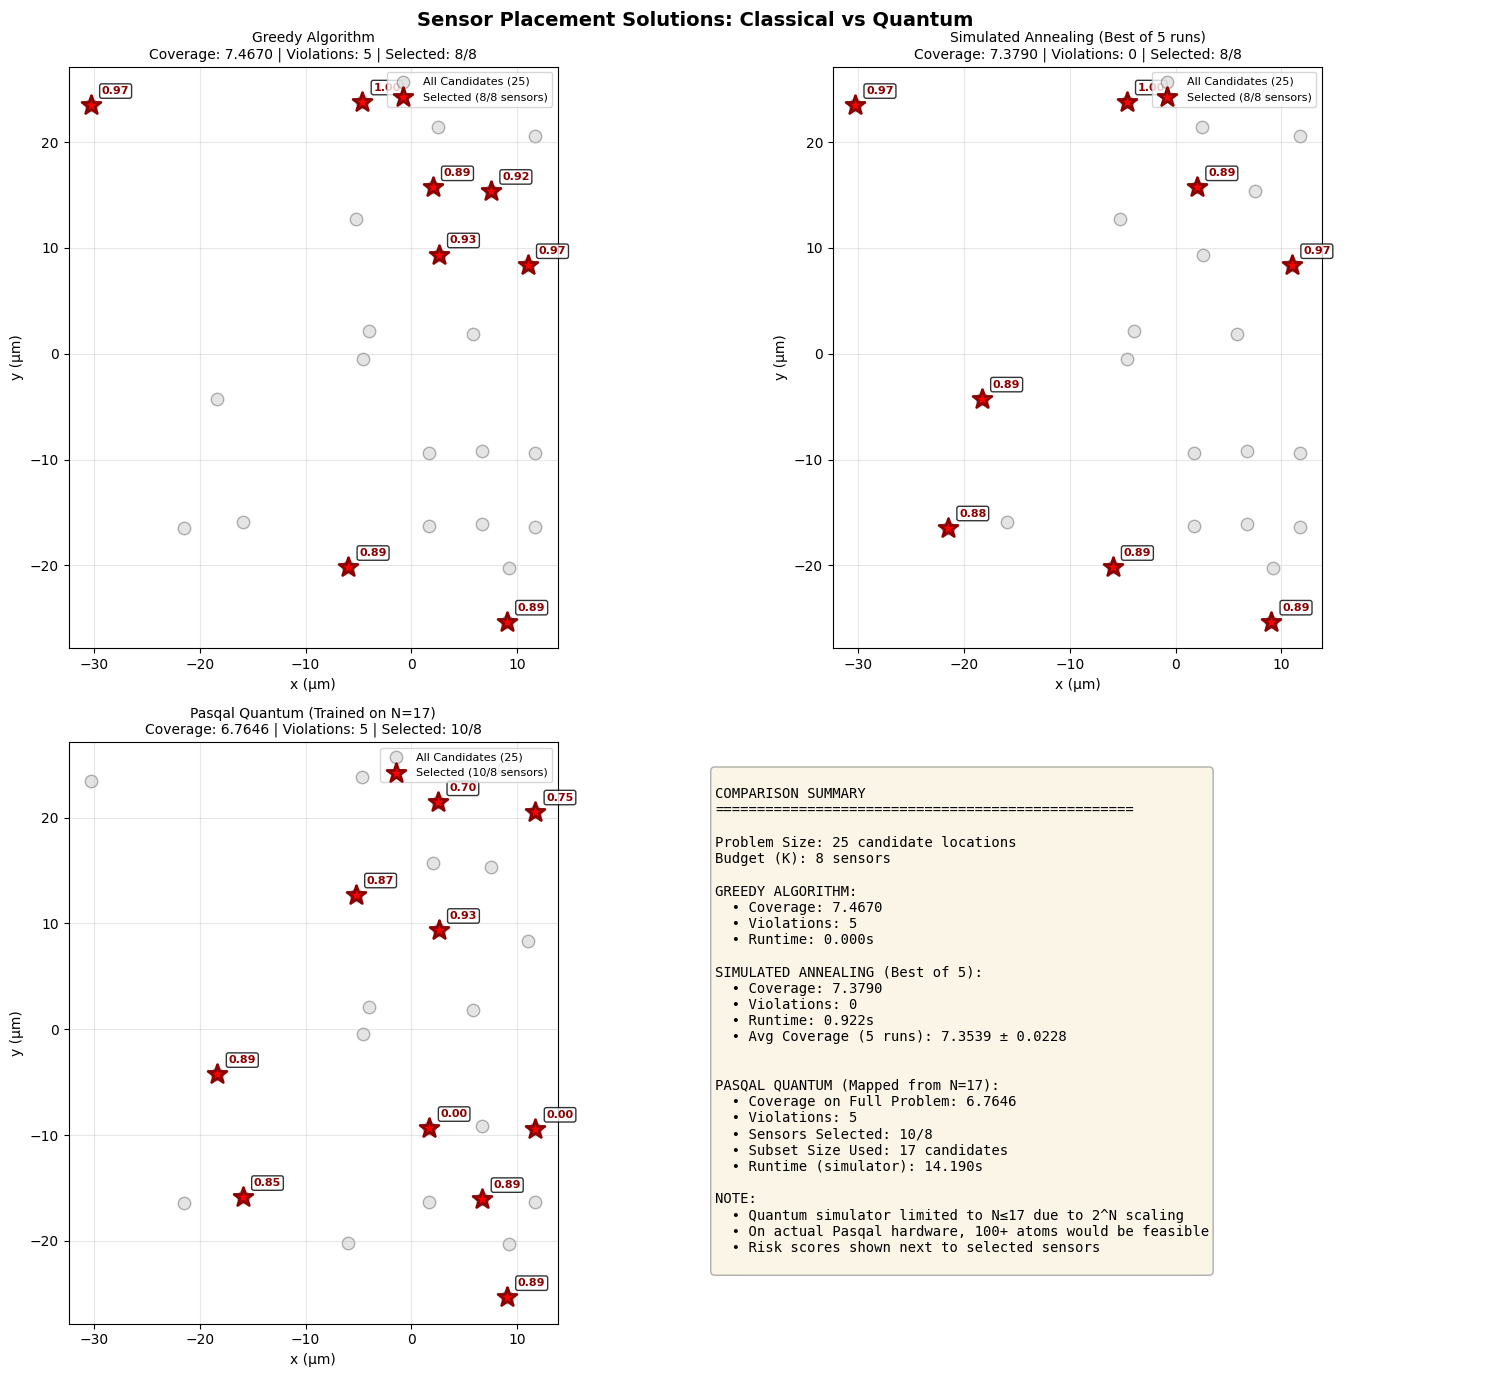


✓ Visualization saved: benchmark_results/all_solutions_comparison.png


In [12]:
# ── 8. Visualization: Compare All Solutions on Full Map ──

print("\n" + "="*70)
print("VISUALIZATION: Comparing Classical and Quantum Solutions")
print("="*70)

# Load full coordinates for visualization
all_lats = np.array([c['latitude'] for c in inst_full['candidates']])
all_lons = np.array([c['longitude'] for c in inst_full['candidates']])

# Convert to μm for register visualization (for consistent scaling)
x_m, y_m = latlon_to_cartesian(all_lats, all_lons)
x_um_all, y_um_all, m_per_um = scale_to_pulser_register(x_m, y_m, target_span_um=50.0)

# Get best quantum result (largest subset)
mapped_quantum_results = []
for qr in quantum_results:
    if qr['pasqal'] and 'error' not in qr['pasqal']:
        mapped = map_subset_to_full(qr['pasqal'], qr['inst'], inst_full)
        if mapped:
            mapped_quantum_results.append({
                'N': qr['N'],
                'K': qr['K'],
                **mapped
            })

best_quantum = max(mapped_quantum_results, key=lambda x: x['N']) if mapped_quantum_results else None

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Sensor Placement Solutions: Classical vs Quantum', fontsize=14, weight='bold')

# Helper function to plot a solution
def plot_solution(ax, title, selected_indices, coverage, violations, n_selected, target_k=8):
    # Plot all candidates as gray circles
    ax.scatter(x_um_all, y_um_all, s=80, c='lightgray', edgecolors='gray', 
               linewidth=1, alpha=0.6, label=f'All Candidates (25)', zorder=1)
    
    # Highlight selected sensors
    if selected_indices:
        sel_x = [x_um_all[i] for i in selected_indices]
        sel_y = [y_um_all[i] for i in selected_indices]
        ax.scatter(sel_x, sel_y, s=200, c='red', edgecolors='darkred', 
                   linewidth=2, marker='*', label=f'Selected ({n_selected}/{target_k} sensors)', 
                   zorder=3)
        
        # Add risk score labels for selected sensors
        for i in selected_indices:
            risk = inst_full['candidates'][i]['risk_score_norm']
            ax.annotate(f'{risk:.2f}', 
                       (x_um_all[i], y_um_all[i]), 
                       xytext=(8, 8), 
                       textcoords='offset points',
                       fontsize=8,
                       fontweight='bold',
                       color='darkred',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    
    ax.set_title(f'{title}\nCoverage: {coverage:.4f} | Violations: {violations} | Selected: {n_selected}/{target_k}', 
                 fontsize=10)
    ax.set_xlabel('x (μm)')
    ax.set_ylabel('y (μm)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')

# Plot 1: Greedy Solution
plot_solution(axes[0, 0], 
              'Greedy Algorithm',
              res_greedy_full['selected_indices'],
              res_greedy_full['coverage'],
              res_greedy_full['violations'],
              res_greedy_full['n_selected'])

# Plot 2: Best Simulated Annealing Solution
plot_solution(axes[0, 1], 
              'Simulated Annealing (Best of 5 runs)',
              best_sa_result['selected_indices'],
              best_sa_result['coverage'],
              best_sa_result['violations'],
              best_sa_result['n_selected'])

# Plot 3: Quantum Solution (mapped to full)
if best_quantum:
    plot_solution(axes[1, 0], 
                  f'Pasqal Quantum (Trained on N={best_quantum["subset_N"]})',
                  best_quantum['selected_indices'],
                  best_quantum['coverage'],
                  best_quantum['violations'],
                  best_quantum['n_selected'])

# Plot 4: Summary/Stats Box
ax4 = axes[1, 1]
ax4.axis('off')

# Create summary text
summary_text = f"""
COMPARISON SUMMARY
{'='*50}

Problem Size: 25 candidate locations
Budget (K): 8 sensors

GREEDY ALGORITHM:
  • Coverage: {res_greedy_full['coverage']:.4f}
  • Violations: {res_greedy_full['violations']}
  • Runtime: {res_greedy_full['runtime']:.3f}s

SIMULATED ANNEALING (Best of 5):
  • Coverage: {best_sa_result['coverage']:.4f}
  • Violations: {best_sa_result['violations']}
  • Runtime: {best_sa_result['runtime']:.3f}s
  • Avg Coverage (5 runs): {np.mean(sa_full_cov):.4f} ± {np.std(sa_full_cov):.4f}

"""

if best_quantum:
    summary_text += f"""
PASQAL QUANTUM (Mapped from N={best_quantum['subset_N']}):
  • Coverage on Full Problem: {best_quantum['coverage']:.4f}
  • Violations: {best_quantum['violations']}
  • Sensors Selected: {best_quantum['n_selected']}/8
  • Subset Size Used: {best_quantum['subset_N']} candidates
  • Runtime (simulator): {quantum_results[0]['pasqal']['runtime']:.3f}s

NOTE:
  • Quantum simulator limited to N≤17 due to 2^N scaling
  • On actual Pasqal hardware, 100+ atoms would be feasible
  • Risk scores shown next to selected sensors
"""

ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes,
         fontsize=10, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('benchmark_results/all_solutions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✓ Visualization saved: benchmark_results/all_solutions_comparison.png')

---
## 9. Key Insights

### Pasqal Advantages
1. **Geometric encoding:** Sensor coordinates → atom positions (natural mapping)
2. **Rydberg blockade:** Hardware-enforced spatial separation (atoms <r_block can't both be excited)
3. **Scalability:** 100+ atoms feasible (vs 15 qubits max for CPU gate-model)
4. **Analog evolution:** More efficient than digital gate decomposition for MWIS

### Current Limitations
1. **Global channel only:** All atoms see same detuning (can't encode individual risk weights easily)
   - **Fix:** Use local addressing with `rydberg_local` channel (requires per-atom detuning)
2. **Soft budget constraint:** No hard K-sensor limit in analog Hamiltonian
   - **Mitigation:** Post-select solutions with sum(n_i) ≈ K, or add global penalty term
3. **Simulator speed:** QutipEmulator is slow for N>20 (10+ minutes)
   - **Solution:** Run on actual Pasqal QPU (pending quota approval)
4. **Coordinate scaling:** Real sensors span km, atoms span μm → careful scale mapping needed
